In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR, SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('D:\\ML PROJECTS\\AML lab\\dataset\\HistoricalQuotes.csv')

In [7]:

def preprocess_data(df):
    data = df.copy()
    data['Date'] = pd.to_datetime(data['Date'])
    price_columns = [' Close/Last', ' Open', ' High', ' Low']
    for col in price_columns:
        if col in data.columns:
            data[col] = data[col].str.replace('$', '').astype(float)
    data = data.sort_values('Date').reset_index(drop=True)
    return data

def create_features(data):
    data['MA_5'] = data[' Close/Last'].rolling(window=5).mean()
    data['MA_10'] = data[' Close/Last'].rolling(window=10).mean()
    data['MA_20'] = data[' Close/Last'].rolling(window=20).mean()
    data['Price_Change'] = data[' Close/Last'].diff()
    data['Price_Change_Pct'] = data[' Close/Last'].pct_change()
    data['Volatility'] = data[' Close/Last'].rolling(window=10).std()
    delta = data[' Close/Last'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))
    data['HL_Spread'] = data[' High'] - data[' Low']
    data['OC_Spread'] = data[' Close/Last'] - data[' Open']
    data['Volume_MA'] = data[' Volume'].rolling(window=10).mean()
    data['Volume_Ratio'] = data[' Volume'] / data['Volume_MA']
    for lag in [1, 2, 3, 5]:
        data[f'Close_Lag_{lag}'] = data[' Close/Last'].shift(lag)
        data[f'Volume_Lag_{lag}'] = data[' Volume'].shift(lag)
    return data

def svm_regression_analysis(data):
    print("=== SVM REGRESSION ANALYSIS ===")
    feature_columns = ['MA_5', 'MA_10', 'MA_20', 'Price_Change', 'Price_Change_Pct',
                      'Volatility', 'RSI', 'HL_Spread', 'OC_Spread', ' Volume',
                      'Volume_Ratio', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3',
                      'Close_Lag_5', 'Volume_Lag_1', 'Volume_Lag_2']
    clean_data = data.dropna()
    X = clean_data[feature_columns]
    y = clean_data[' Close/Last']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    kernels = ['linear', 'rbf', 'poly']
    results = {}
    for kernel in kernels:
        print(f"\nTraining SVM with {kernel} kernel...")
        if kernel == 'linear':
            svm_model = SVR(kernel=kernel, C=1.0)
        elif kernel == 'rbf':
            svm_model = SVR(kernel=kernel, C=1.0, gamma='scale')
        else:
            svm_model = SVR(kernel=kernel, C=1.0, degree=3)
        svm_model.fit(X_train_scaled, y_train_scaled)
        y_pred_scaled = svm_model.predict(X_test_scaled)
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        results[kernel] = {
            'model': svm_model,
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'predictions': y_pred
        }
        print(f"  MSE: {mse:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE: {mae:.4f}")
    best_kernel = min(results.keys(), key=lambda k: results[k]['rmse'])
    print(f"\nBest kernel: {best_kernel} (RMSE: {results[best_kernel]['rmse']:.4f})")
    return results, X_test, y_test, scaler_X, scaler_y

def svm_classification_analysis(data):
    print("\n=== SVM CLASSIFICATION ANALYSIS ===")
    data['Price_Direction'] = np.where(data['Price_Change'] > 0, 1, 0)
    feature_columns = ['MA_5', 'MA_10', 'MA_20', 'Price_Change_Pct',
                      'Volatility', 'RSI', 'HL_Spread', 'OC_Spread', ' Volume',
                      'Volume_Ratio', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3']
    clean_data = data.dropna()
    X = clean_data[feature_columns]
    y = clean_data['Price_Direction']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    kernels = ['linear', 'rbf', 'poly']
    classification_results = {}
    for kernel in kernels:
        print(f"\nTraining SVM Classifier with {kernel} kernel...")
        if kernel == 'linear':
            svm_classifier = SVC(kernel=kernel, C=1.0, random_state=42)
        elif kernel == 'rbf':
            svm_classifier = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)
        else:
            svm_classifier = SVC(kernel=kernel, C=1.0, degree=3, random_state=42)
        svm_classifier.fit(X_train_scaled, y_train)
        y_pred = svm_classifier.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        classification_results[kernel] = {
            'model': svm_classifier,
            'accuracy': accuracy,
            'predictions': y_pred
        }
        print(f"  Accuracy: {accuracy:.4f}")
        print("  Classification Report:")
        print(classification_report(y_test, y_pred, target_names=['Down', 'Up']))
    best_kernel = max(classification_results.keys(), key=lambda k: classification_results[k]['accuracy'])
    print(f"\nBest classifier kernel: {best_kernel} (Accuracy: {classification_results[best_kernel]['accuracy']:.4f})")
    return classification_results

def hyperparameter_tuning(X_train, y_train):
    print("\n=== HYPERPARAMETER TUNING ===")
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
        'kernel': ['rbf', 'linear']
    }
    svm = SVR()
    grid_search = GridSearchCV(
        svm, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
    return grid_search.best_estimator_

def plot_results(results, X_test, y_test):
    plt.figure(figsize=(15, 10))
    for i, (kernel, result) in enumerate(results.items(), 1):
        plt.subplot(2, 2, i)
        plt.scatter(range(len(y_test)), y_test, alpha=0.6, label='Actual', s=10)
        plt.scatter(range(len(result['predictions'])), result['predictions'], 
                   alpha=0.6, label='Predicted', s=10)
        plt.title(f'SVM {kernel.upper()} Kernel - RMSE: {result["rmse"]:.4f}')
        plt.xlabel('Time')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()




def main():
    if __name__ == "__main__":
        main()

=== SVM REGRESSION ANALYSIS ===

Training SVM with linear kernel...
  MSE: 9.5713
  RMSE: 3.0938
  MAE: 2.0600

Training SVM with rbf kernel...
  MSE: 8082.0549
  RMSE: 89.9002
  MAE: 64.3955

Training SVM with poly kernel...
  MSE: 305475.9823
  RMSE: 552.6988
  MAE: 298.2625

Best kernel: linear (RMSE: 3.0938)

=== SVM CLASSIFICATION ANALYSIS ===

Training SVM Classifier with linear kernel...
  Accuracy: 0.9920
  Classification Report:
              precision    recall  f1-score   support

        Down       0.99      1.00      0.99       227
          Up       1.00      0.99      0.99       273

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500


Training SVM Classifier with rbf kernel...
  Accuracy: 0.8080
  Classification Report:
              precision    recall  f1-score   support

        Down       0.71      0.99      0.82       227
          Up       0.98      0.66 

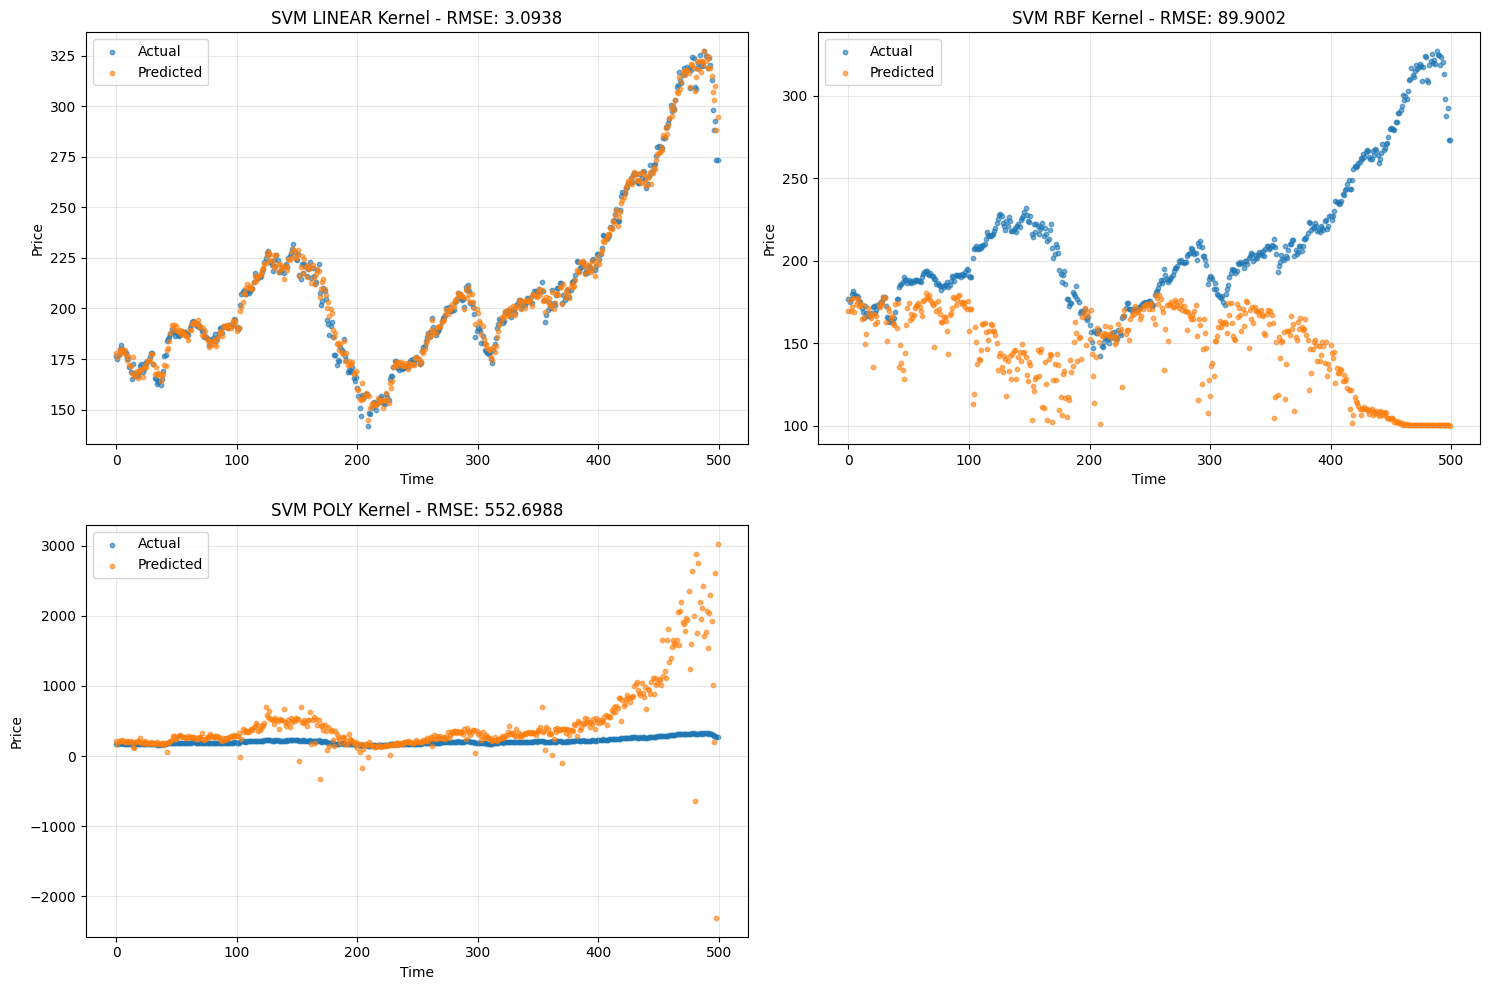

In [8]:
df = pd.read_csv('D:\\ML PROJECTS\\AML lab\\dataset\\HistoricalQuotes.csv')
data = preprocess_data(df)
data = create_features(data)
regression_results, X_test, y_test, scaler_X, scaler_y = svm_regression_analysis(data)
classification_results = svm_classification_analysis(data)
plot_results(regression_results, X_test, y_test)

=== SVM REGRESSION ANALYSIS ===

Training SVM with linear kernel...
  MSE: 9.5713
  RMSE: 3.0938
  MAE: 2.0600

Training SVM with rbf kernel...
  MSE: 8082.0549
  RMSE: 89.9002
  MAE: 64.3955

Training SVM with poly kernel...
  MSE: 305475.9823
  RMSE: 552.6988
  MAE: 298.2625

Best kernel: linear (RMSE: 3.0938)

=== SVM CLASSIFICATION ANALYSIS ===

Training SVM Classifier with linear kernel...
  Accuracy: 0.9920
  Classification Report:
              precision    recall  f1-score   support

        Down       0.99      1.00      0.99       227
          Up       1.00      0.99      0.99       273

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500


Training SVM Classifier with rbf kernel...
  Accuracy: 0.8080
  Classification Report:
              precision    recall  f1-score   support

        Down       0.71      0.99      0.82       227
          Up       0.98      0.66 

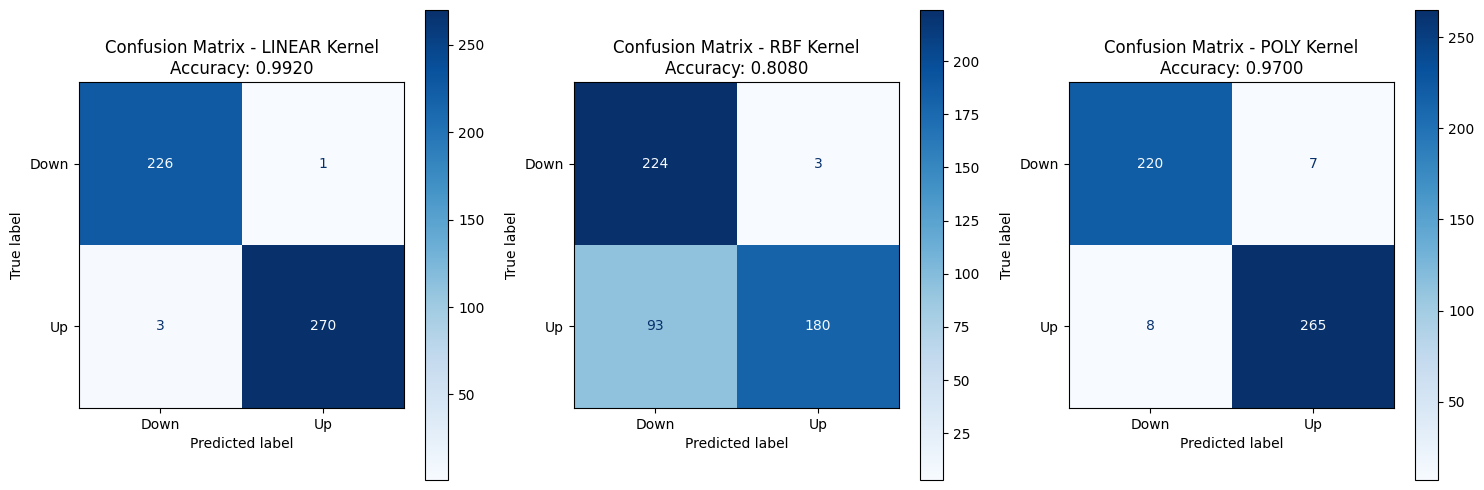

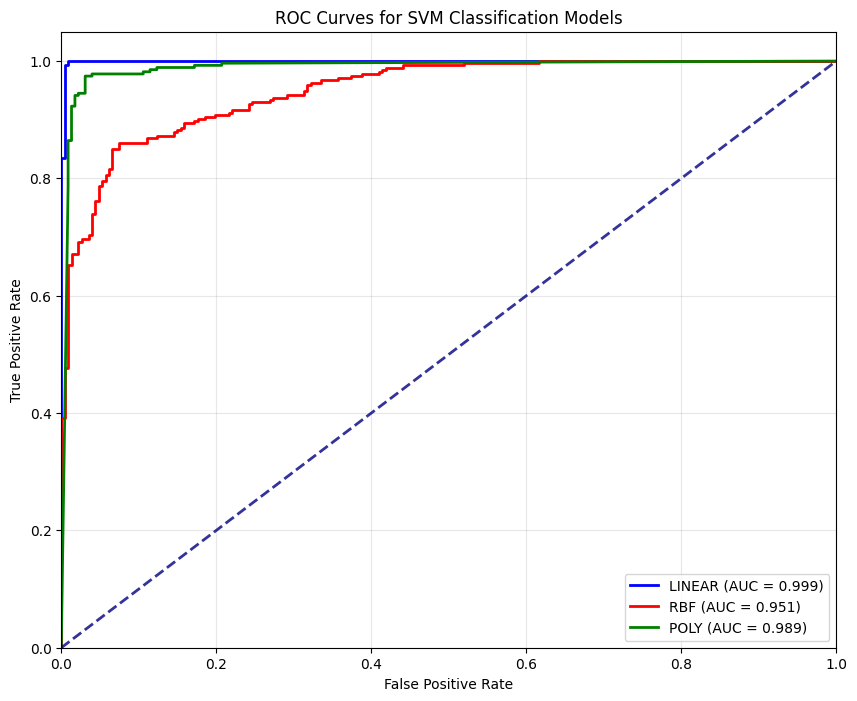

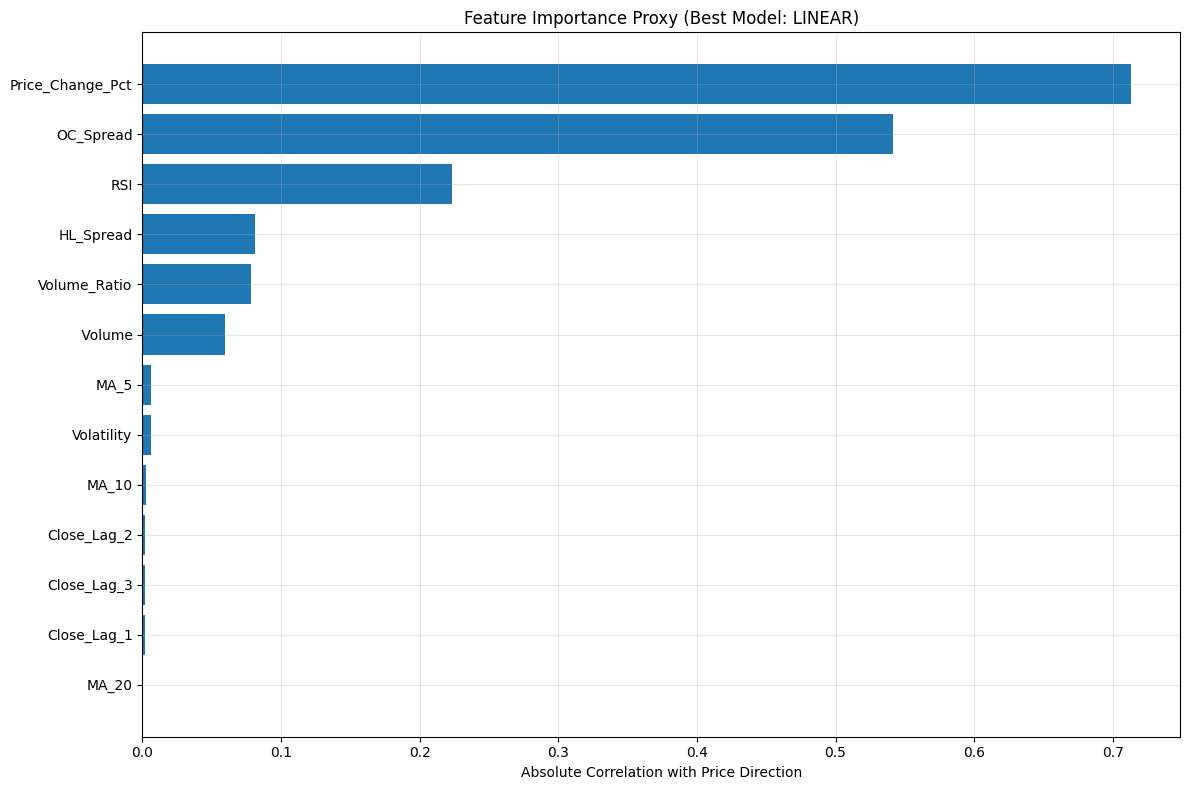

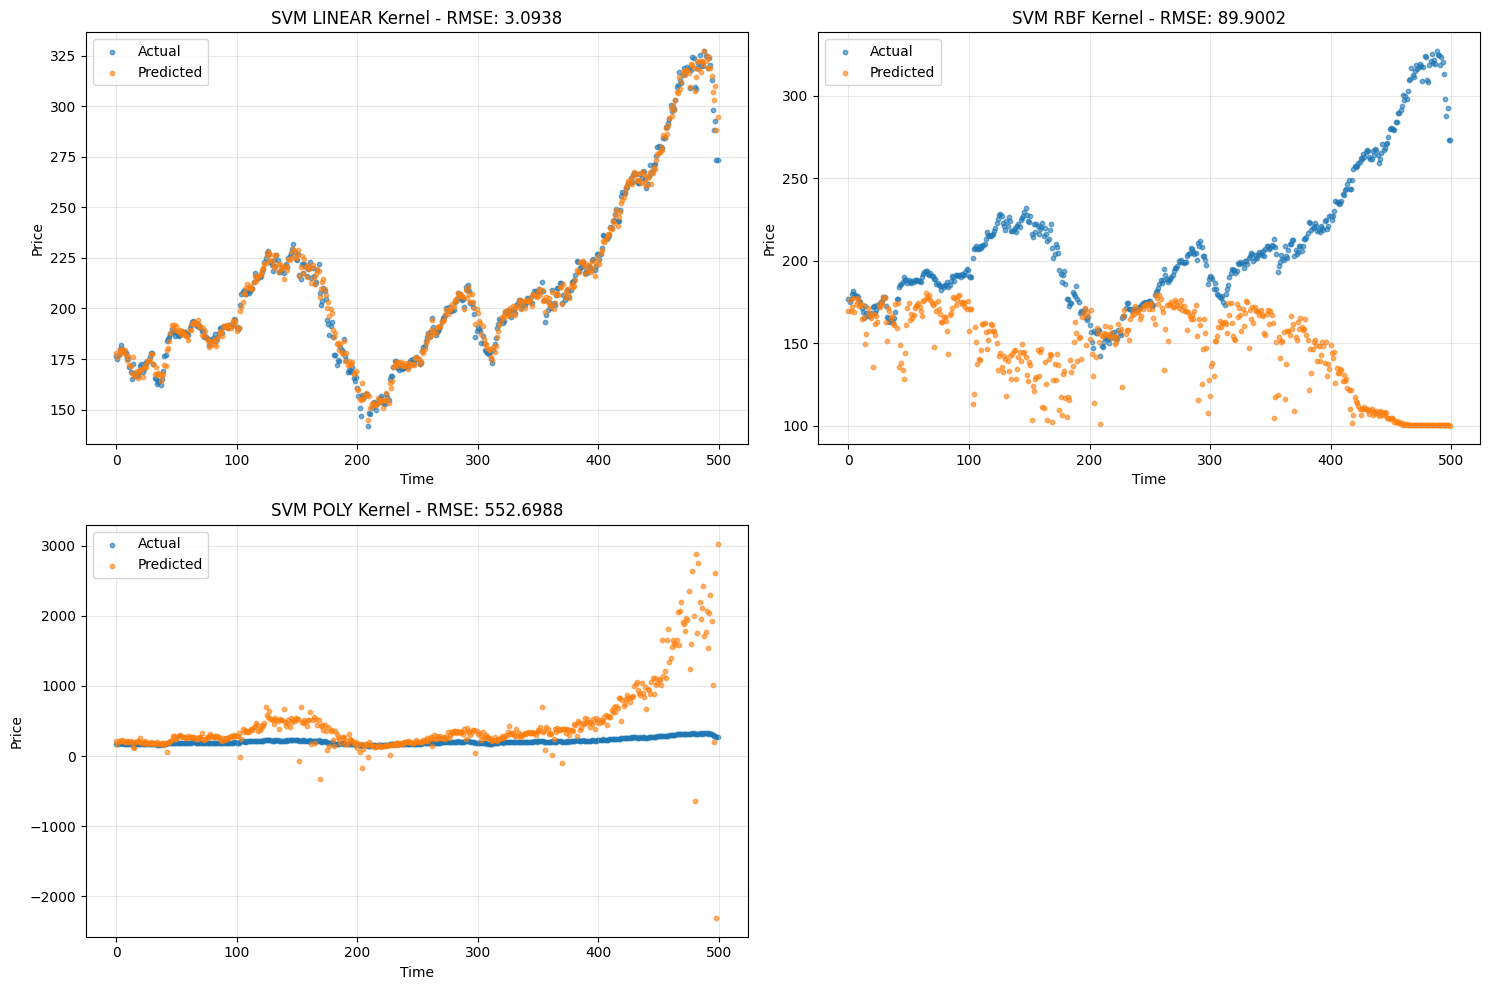

Analysis complete! New visualizations added:
1. Confusion matrices for all SVM classification models
2. ROC curves showing model performance comparison
3. Feature importance proxy using correlations


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR, SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, accuracy_score, 
                           classification_report, confusion_matrix, roc_curve, auc)
from sklearn.metrics import ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

def preprocess_data(df):
    data = df.copy()
    data['Date'] = pd.to_datetime(data['Date'])
    price_columns = [' Close/Last', ' Open', ' High', ' Low']
    for col in price_columns:
        if col in data.columns:
            data[col] = data[col].str.replace('$', '').astype(float)
    data = data.sort_values('Date').reset_index(drop=True)
    return data

def create_features(data):
    data['MA_5'] = data[' Close/Last'].rolling(window=5).mean()
    data['MA_10'] = data[' Close/Last'].rolling(window=10).mean()
    data['MA_20'] = data[' Close/Last'].rolling(window=20).mean()
    data['Price_Change'] = data[' Close/Last'].diff()
    data['Price_Change_Pct'] = data[' Close/Last'].pct_change()
    data['Volatility'] = data[' Close/Last'].rolling(window=10).std()
    delta = data[' Close/Last'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))
    data['HL_Spread'] = data[' High'] - data[' Low']
    data['OC_Spread'] = data[' Close/Last'] - data[' Open']
    data['Volume_MA'] = data[' Volume'].rolling(window=10).mean()
    data['Volume_Ratio'] = data[' Volume'] / data['Volume_MA']
    for lag in [1, 2, 3, 5]:
        data[f'Close_Lag_{lag}'] = data[' Close/Last'].shift(lag)
        data[f'Volume_Lag_{lag}'] = data[' Volume'].shift(lag)
    return data

def svm_regression_analysis(data):
    print("=== SVM REGRESSION ANALYSIS ===")
    feature_columns = ['MA_5', 'MA_10', 'MA_20', 'Price_Change', 'Price_Change_Pct',
                      'Volatility', 'RSI', 'HL_Spread', 'OC_Spread', ' Volume',
                      'Volume_Ratio', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3',
                      'Close_Lag_5', 'Volume_Lag_1', 'Volume_Lag_2']
    clean_data = data.dropna()
    X = clean_data[feature_columns]
    y = clean_data[' Close/Last']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    kernels = ['linear', 'rbf', 'poly']
    results = {}
    for kernel in kernels:
        print(f"\nTraining SVM with {kernel} kernel...")
        if kernel == 'linear':
            svm_model = SVR(kernel=kernel, C=1.0)
        elif kernel == 'rbf':
            svm_model = SVR(kernel=kernel, C=1.0, gamma='scale')
        else:
            svm_model = SVR(kernel=kernel, C=1.0, degree=3)
        svm_model.fit(X_train_scaled, y_train_scaled)
        y_pred_scaled = svm_model.predict(X_test_scaled)
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        results[kernel] = {
            'model': svm_model,
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'predictions': y_pred
        }
        print(f"  MSE: {mse:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE: {mae:.4f}")
    best_kernel = min(results.keys(), key=lambda k: results[k]['rmse'])
    print(f"\nBest kernel: {best_kernel} (RMSE: {results[best_kernel]['rmse']:.4f})")
    return results, X_test, y_test, scaler_X, scaler_y

def svm_classification_analysis(data):
    print("\n=== SVM CLASSIFICATION ANALYSIS ===")
    data['Price_Direction'] = np.where(data['Price_Change'] > 0, 1, 0)
    feature_columns = ['MA_5', 'MA_10', 'MA_20', 'Price_Change_Pct',
                      'Volatility', 'RSI', 'HL_Spread', 'OC_Spread', ' Volume',
                      'Volume_Ratio', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3']
    clean_data = data.dropna()
    X = clean_data[feature_columns]
    y = clean_data['Price_Direction']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    kernels = ['linear', 'rbf', 'poly']
    classification_results = {}
    for kernel in kernels:
        print(f"\nTraining SVM Classifier with {kernel} kernel...")
        if kernel == 'linear':
            svm_classifier = SVC(kernel=kernel, C=1.0, random_state=42, probability=True)
        elif kernel == 'rbf':
            svm_classifier = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42, probability=True)
        else:
            svm_classifier = SVC(kernel=kernel, C=1.0, degree=3, random_state=42, probability=True)
        svm_classifier.fit(X_train_scaled, y_train)
        y_pred = svm_classifier.predict(X_test_scaled)
        y_pred_proba = svm_classifier.predict_proba(X_test_scaled)[:, 1]
        accuracy = accuracy_score(y_test, y_pred)
        classification_results[kernel] = {
            'model': svm_classifier,
            'accuracy': accuracy,
            'predictions': y_pred,
            'probabilities': y_pred_proba,
            'y_test': y_test
        }
        print(f"  Accuracy: {accuracy:.4f}")
        print("  Classification Report:")
        print(classification_report(y_test, y_pred, target_names=['Down', 'Up']))
    best_kernel = max(classification_results.keys(), key=lambda k: classification_results[k]['accuracy'])
    print(f"\nBest classifier kernel: {best_kernel} (Accuracy: {classification_results[best_kernel]['accuracy']:.4f})")
    return classification_results

def plot_confusion_matrices(classification_results):
    """Generate confusion matrices for all SVM classification models"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for i, (kernel, result) in enumerate(classification_results.items()):
        cm = confusion_matrix(result['y_test'], result['predictions'])
        
        # Create confusion matrix display
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                    display_labels=['Down', 'Up'])
        disp.plot(ax=axes[i], cmap='Blues', values_format='d')
        axes[i].set_title(f'Confusion Matrix - {kernel.upper()} Kernel\n'
                         f'Accuracy: {result["accuracy"]:.4f}')
        axes[i].grid(False)
    
    plt.tight_layout()
    plt.show()

def plot_roc_curves(classification_results):
    """Generate ROC curves for all SVM classification models"""
    plt.figure(figsize=(10, 8))
    
    colors = ['blue', 'red', 'green']
    
    for i, (kernel, result) in enumerate(classification_results.items()):
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(result['y_test'], result['probabilities'])
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, color=colors[i], lw=2, 
                label=f'{kernel.upper()} (AUC = {roc_auc:.3f})')
    
    # Plot diagonal line
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.8)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for SVM Classification Models')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_feature_importance_proxy(data, classification_results):
    """Plot feature correlation with target variable as a proxy for feature importance"""
    # Get the best performing model
    best_kernel = max(classification_results.keys(), 
                     key=lambda k: classification_results[k]['accuracy'])
    
    # Prepare the data
    data['Price_Direction'] = np.where(data['Price_Change'] > 0, 1, 0)
    feature_columns = ['MA_5', 'MA_10', 'MA_20', 'Price_Change_Pct',
                      'Volatility', 'RSI', 'HL_Spread', 'OC_Spread', ' Volume',
                      'Volume_Ratio', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3']
    
    clean_data = data.dropna()
    
    # Calculate correlations
    correlations = []
    for feature in feature_columns:
        corr = clean_data[feature].corr(clean_data['Price_Direction'])
        correlations.append(abs(corr))  # Use absolute correlation
    
    # Create feature importance plot
    plt.figure(figsize=(12, 8))
    feature_importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': correlations
    }).sort_values('Importance', ascending=True)
    
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
    plt.xlabel('Absolute Correlation with Price Direction')
    plt.title(f'Feature Importance Proxy (Best Model: {best_kernel.upper()})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def hyperparameter_tuning(X_train, y_train):
    print("\n=== HYPERPARAMETER TUNING ===")
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
        'kernel': ['rbf', 'linear']
    }
    svm = SVR()
    grid_search = GridSearchCV(
        svm, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
    return grid_search.best_estimator_

def plot_results(results, X_test, y_test):
    plt.figure(figsize=(15, 10))
    for i, (kernel, result) in enumerate(results.items(), 1):
        plt.subplot(2, 2, i)
        plt.scatter(range(len(y_test)), y_test, alpha=0.6, label='Actual', s=10)
        plt.scatter(range(len(result['predictions'])), result['predictions'], 
                   alpha=0.6, label='Predicted', s=10)
        plt.title(f'SVM {kernel.upper()} Kernel - RMSE: {result["rmse"]:.4f}')
        plt.xlabel('Time')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def main():
    #
    # df = pd.read_csv('your_stock_data.csv')
   
    data = preprocess_data(df)
    data = create_features(data)
    

    regression_results, X_test, y_test, scaler_X, scaler_y = svm_regression_analysis(data)
    

    classification_results = svm_classification_analysis(data)
    

    plot_confusion_matrices(classification_results)
    plot_roc_curves(classification_results)
    plot_feature_importance_proxy(data, classification_results)
    plot_results(regression_results, X_test, y_test)
    
    print("Analysis complete! New visualizations added:")
    print("1. Confusion matrices for all SVM classification models")
    print("2. ROC curves showing model performance comparison")
    print("3. Feature importance proxy using correlations")

if __name__ == "__main__":
    main()